# Read iGEM Data

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Outputs go to today's run folder, assets/<date>/00/ (see run_paths.py at the repo root).
sys.path.insert(0, str(Path.cwd().parent))
from run_paths import open_run

RUN = open_run("00")

Run 2026-09-21 · stage 00 → /Users/cristian/Desktop/GitHub/igem-synbio/assets/2026-09-21/00


## Load files

In [2]:
projects_text = pd.read_csv(
    "/Users/cristian/Library/CloudStorage/GoogleDrive-cristianmejia00@gmail.com/My Drive/SynBio/igem_teams/team_project_descriptions_manual_entries_v2.tsv",
    sep="\t",
    encoding="iso-8859-1"
)

team_meta_full = pd.read_csv(
    "/Users/cristian/Library/CloudStorage/GoogleDrive-cristianmejia00@gmail.com/My Drive/SynBio/igem_teams/team_meta_full.tsv",
    sep="\t",
    encoding="utf-8"
)

In [3]:
team_meta_full['Status'].value_counts()

Status
accepted        4883
withdrawn        186
disqualified      27
Name: count, dtype: int64

## Work with non-highschool, accepted teams

In [4]:
team_meta_full = team_meta_full[team_meta_full['Status'] == 'accepted']
team_meta_full = team_meta_full[team_meta_full['Section'] != 'high-school']

In [5]:
team_meta_full.head()


,TeamID,Team,Region,Country,Kind,Section,Status,Year,WikiURL,SoftwareURL,...,IsRemote,Track,Topics,InstitutionCity,InstitutionName,InstitutionState,InstitutionCountry,Competition,JudgingStart,JudgingEnd
0,5260,ABOA,europe,FIN,NaN,overgrad,accepted,2024,https://2024.igem.wiki/aboa,NaN,...,False,Space,In situ Resource Utilization; Life Support; Sp...,Turku,University of Turku,NaN,FIN,igem,2024-10-25T07:10:00.000Z,2024-10-25T07:20:00.000Z
1,5794,ABOA,europe,FIN,NaN,overgrad,accepted,2025,https://2025.igem.wiki/aboa,NaN,...,False,Diagnostics,CRISPR/Cas9; Vector-borne diseases - targeting...,Turku,University of Turku,NaN,FIN,igem,2025-10-29T16:00:00.000Z,2025-10-29T16:30:00.000Z
2,4831,ABOA-Turku,europe,FIN,NaN,overgrad,accepted,2023,https://2023.igem.wiki/aboa-turku,https://gitlab.igem.org/2023/software-tools/ab...,...,False,Bioremediation,Plastics and microplastics; Polycyclic aromati...,NaN,"University of Turku, Turku, Finland (www.utu.f...",NaN,NaN,igem,2023-11-02T11:00:00.000Z,2023-11-02T11:30:00.000Z
3,4068,ABSI_Kenya,africa,KEN,NaN,collegiate,accepted,2021,https://2021.igem.org/Team:ABSI_Kenya,NaN,...,False,Environment,Local environment pollution; Ocean pollution; ...,NaN,"Community Laboratory, Nairobi Kenya.",NaN,NaN,igem,NaN,NaN
4,2815,ACIBADEM_ISTANBUL,asia,TUR,NaN,undergrad,accepted,2018,https://2018.igem.org/Team:ACIBADEM_ISTANBUL,NaN,...,False,Therapeutics,NaN,NaN,"ACIBADEM MEHMET ALI AYDINLAR UNIVERSITY, ISTAN...",NaN,NaN,igem,NaN,NaN


## Merge by team ID

In [6]:
df = team_meta_full.merge(projects_text, on='TeamID', how='left')

count_projectabstract = (
    df["ProjectAbstract"]
    .astype("string")
    .str.strip()
    .replace({"": pd.NA, "nan": pd.NA, "NaN": pd.NA, "NAN": pd.NA})
    .notna()
    .sum()
)

print(count_projectabstract)

3811


## Get teams with descriptions

In [7]:
df = df[df['ProjectAbstract'].notna()]

## Column mapping

In [8]:
df.columns.tolist()

['TeamID',
 'Team_x',
 'Region',
 'Country',
 'Kind',
 'Section',
 'Status',
 'Year_x',
 'WikiURL',
 'SoftwareURL',
 'ApplicationDate',
 'IsRemote',
 'Track',
 'Topics',
 'InstitutionCity',
 'InstitutionName',
 'InstitutionState',
 'InstitutionCountry',
 'Competition',
 'JudgingStart',
 'JudgingEnd',
 'Year_y',
 'Team_y',
 'ProjectTitle',
 'ProjectAbstract']

In [9]:
dff = df.rename(columns={
    'TeamID': 'UT',
    'ProjectTitle': 'TI',
    'ProjectAbstract': 'AB',
    'Year_x': 'PY',
    'Team_x': 'AU',
    'Topics': 'WC',
    'WikiURL': 'DI',
    'Track': 'ID',
    'Country': 'Countries',
    'InstitutionName': 'Institutions',
})

dff['CR'] = ''
dff['C1'] = ''

## Summary statistics

In [10]:
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}\n')
print(f'Year range: {df["Year_x"].min()} – {df["Year_x"].max()}')
print(f'Unique countries: {df["Country"].nunique()}')
print(f'Unique institutions: {df["InstitutionName"].nunique()}')
print(f'Unique tracks: {df["Track"].nunique()}')
print(f'Unique topics: {df["Topics"].nunique()}')

Shape: (3811, 25)
Columns: ['TeamID', 'Team_x', 'Region', 'Country', 'Kind', 'Section', 'Status', 'Year_x', 'WikiURL', 'SoftwareURL', 'ApplicationDate', 'IsRemote', 'Track', 'Topics', 'InstitutionCity', 'InstitutionName', 'InstitutionState', 'InstitutionCountry', 'Competition', 'JudgingStart', 'JudgingEnd', 'Year_y', 'Team_y', 'ProjectTitle', 'ProjectAbstract']

Year range: 2004 – 2025
Unique countries: 66
Unique institutions: 2847
Unique tracks: 30
Unique topics: 15


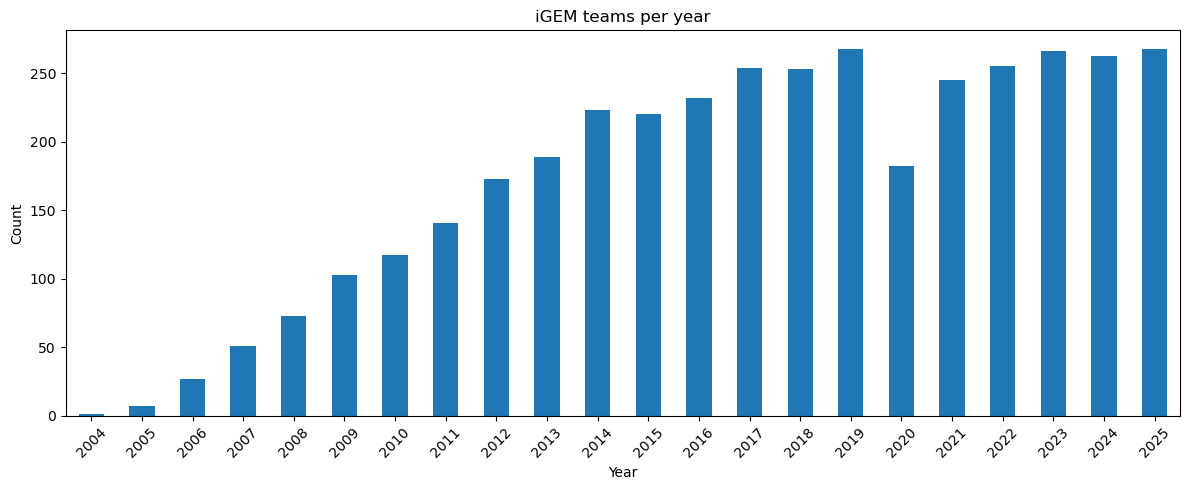

In [11]:
# Teams per year
yearly = df['Year_x'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
yearly.plot(kind='bar', ax=ax)
ax.set_title('iGEM teams per year')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

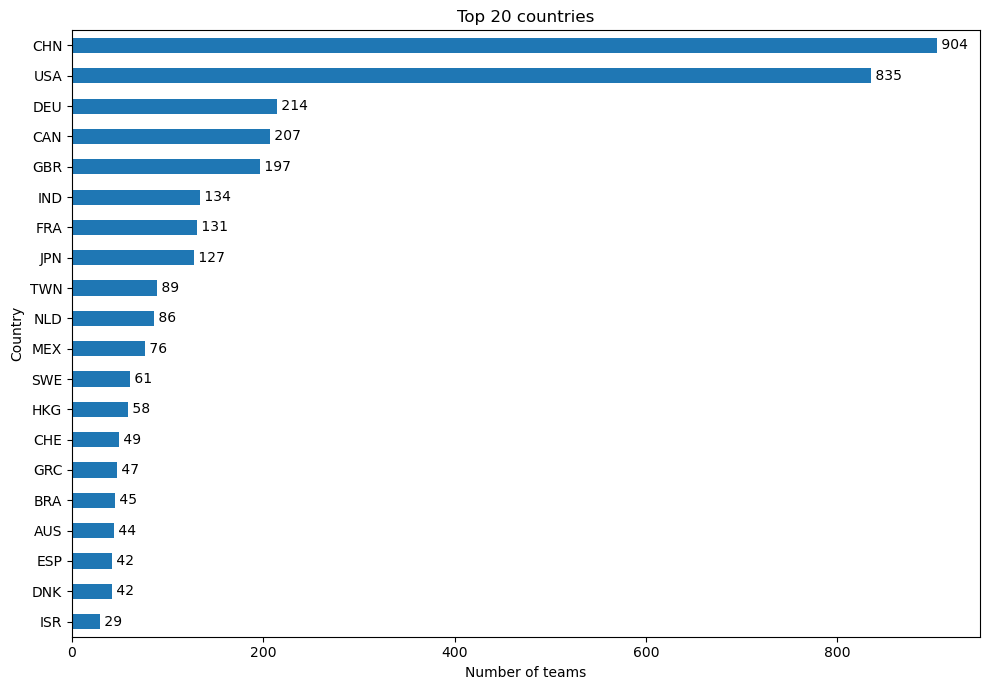

In [12]:
# Top 20 countries
top_countries = df['Country'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_countries.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Number of teams')
ax.set_title('Top 20 countries')
for i, v in enumerate(top_countries):
    ax.text(v, i, f' {v:,}', va='center')
plt.tight_layout()
plt.show()

) missing from font(s) DejaVu Sans.tm9jr0000gn/T/ipykernel_57060/3029084321.py:11: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


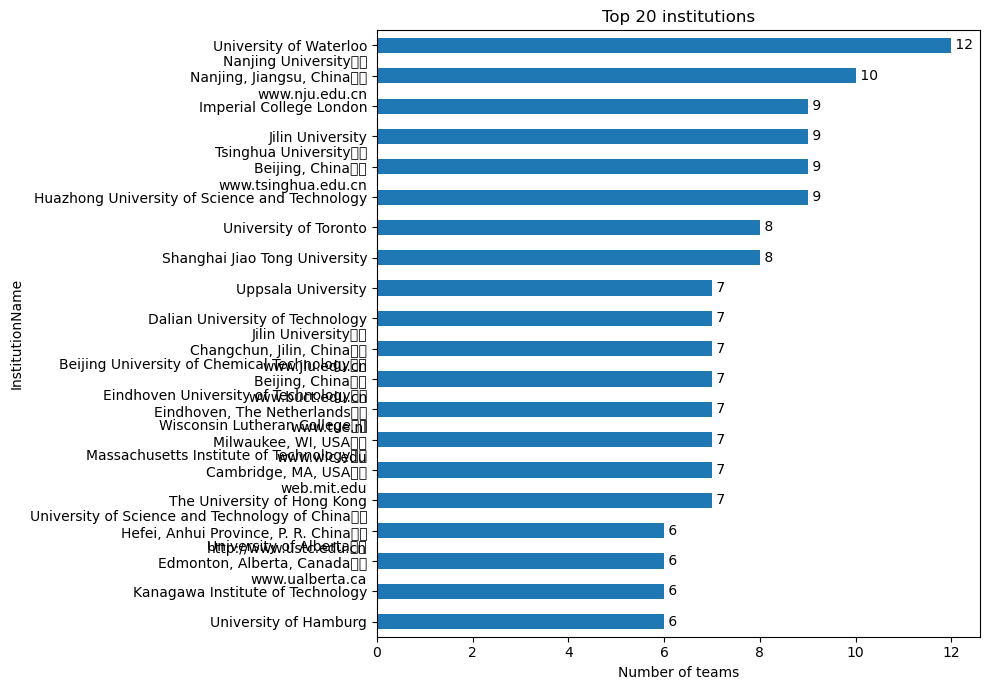

In [13]:
# Top 20 institutions
top_inst = df['InstitutionName'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_inst.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Number of teams')
ax.set_title('Top 20 institutions')
for i, v in enumerate(top_inst):
    ax.text(v, i, f' {v:,}', va='center')
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Teams per section'}, xlabel='Section'>

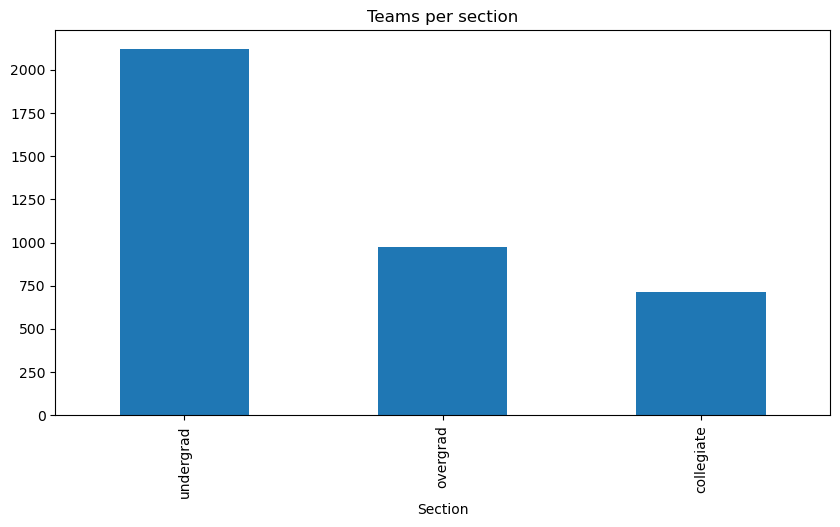

In [14]:
df.Section.value_counts().plot(kind='bar', figsize=(10, 5), title='Teams per section')

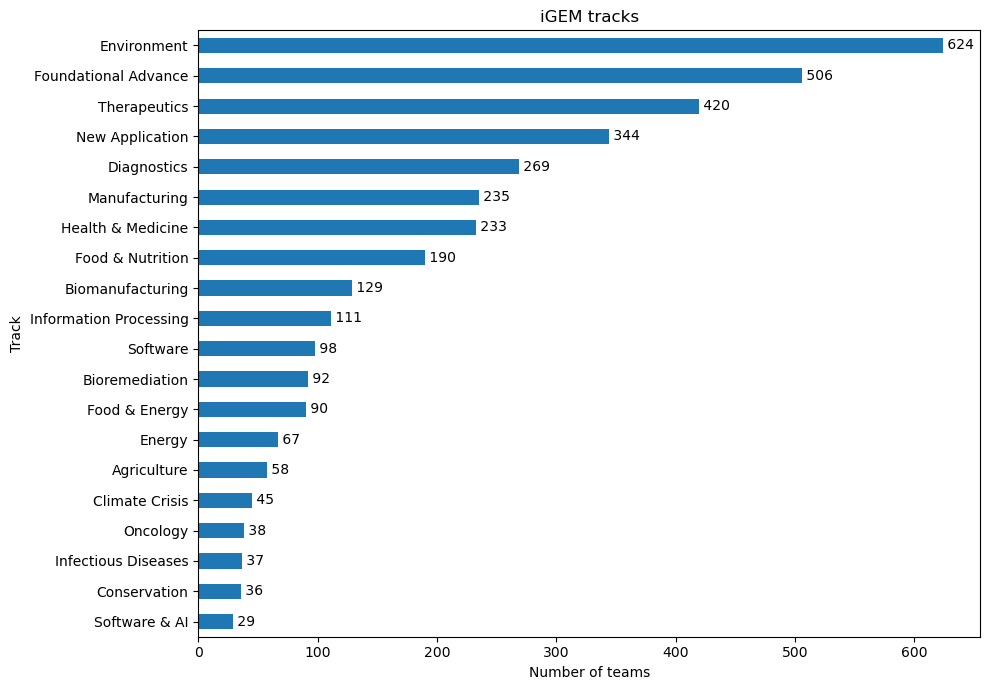

In [15]:
# Tracks
top_tracks = df['Track'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_tracks.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Number of teams')
ax.set_title('iGEM tracks')
for i, v in enumerate(top_tracks):
    ax.text(v, i, f' {v:,}', va='center')
plt.tight_layout()
plt.show()

/var/folders/l3/ykgptl812qndpwdm6n3tm9jr0000gn/T/ipykernel_57060/1695386552.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


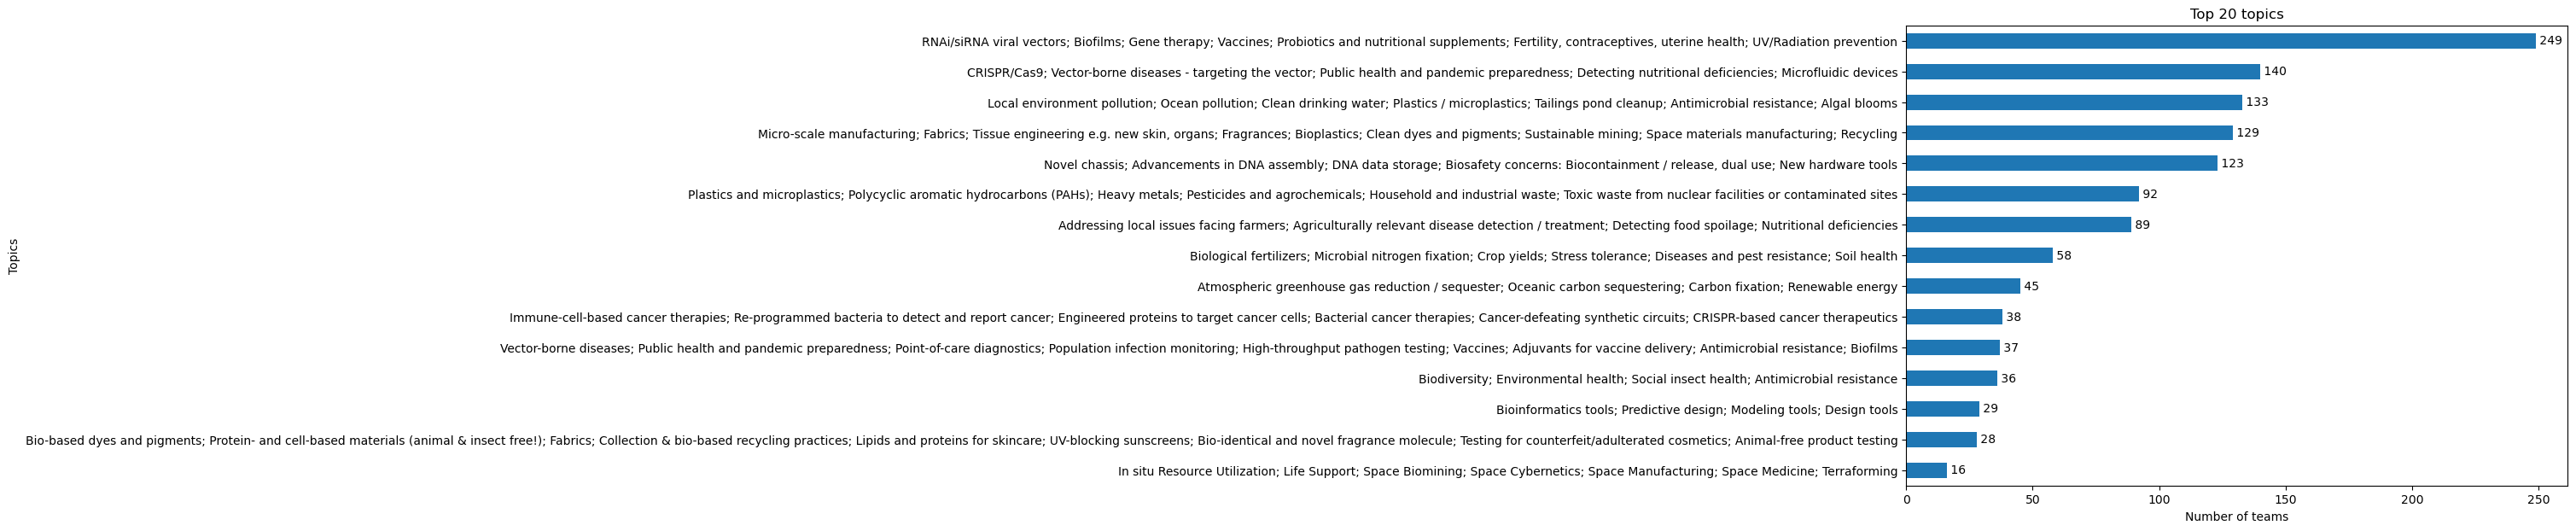

In [16]:
# Top 20 topics
top_topics = df['Topics'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_topics.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Number of teams')
ax.set_title('Top 20 topics')
for i, v in enumerate(top_topics):
    ax.text(v, i, f' {v:,}', va='center')
plt.tight_layout()
plt.show()

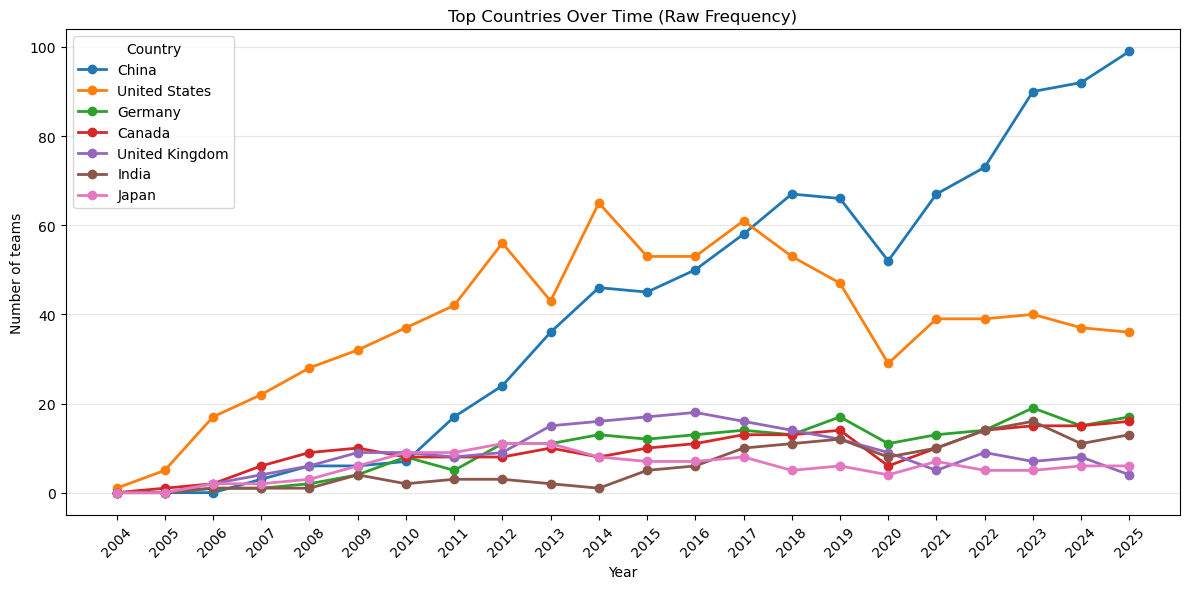

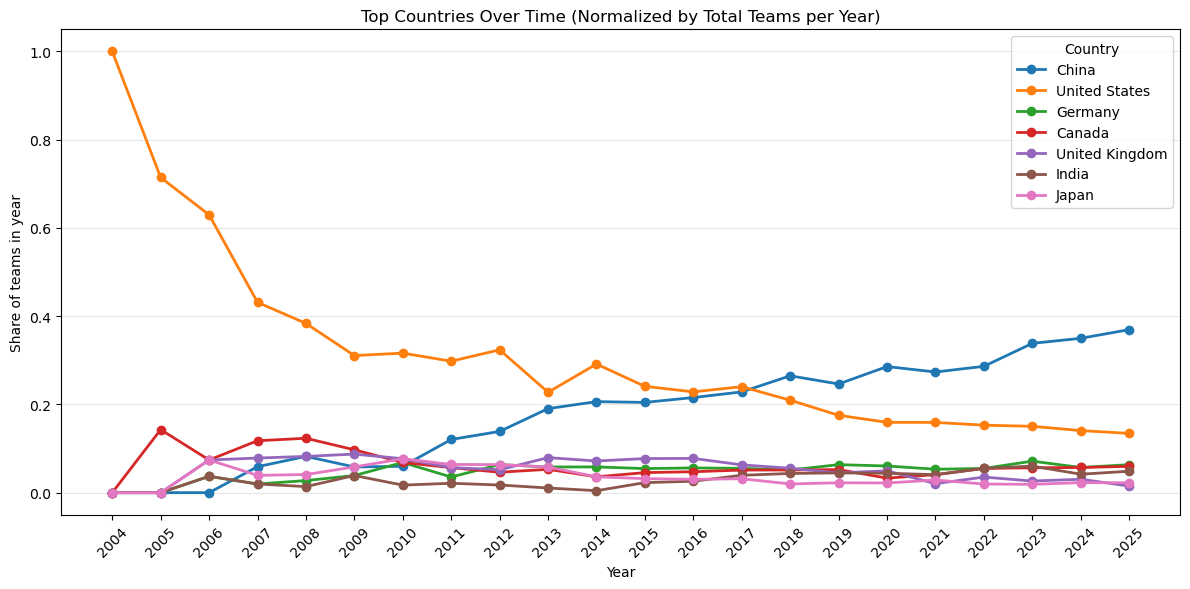

In [17]:
# Top countries over time: raw and normalized frequencies (plus any in ALWAYS_SHOW)
n_top = 6

plot_df = df[['Year_x', 'Country']].dropna().copy()
plot_df['Country'] = plot_df['Country'].astype(str).str.strip()
plot_df = plot_df[plot_df['Country'] != '']

# Keep years sorted and numeric when possible
plot_df['Year_x'] = pd.to_numeric(plot_df['Year_x'], errors='coerce')
plot_df = plot_df.dropna(subset=['Year_x'])
plot_df['Year_x'] = plot_df['Year_x'].astype(int)

years = sorted(plot_df['Year_x'].unique())

top_countries_overall = plot_df['Country'].value_counts().head(n_top).index.tolist()

# Countries always drawn in addition to the top n_top (a presentation choice; [] for none)
ALWAYS_SHOW = ['JPN']
for code in ALWAYS_SHOW:
    if code not in top_countries_overall and (plot_df['Country'] == code).any():
        top_countries_overall.append(code)

country_year_counts = (
    plot_df[plot_df['Country'].isin(top_countries_overall)]
    .groupby(['Year_x', 'Country'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=years, columns=top_countries_overall, fill_value=0)
)

total_teams_per_year = (
    plot_df.groupby('Year_x')
    .size()
    .reindex(years, fill_value=0)
)

country_year_norm = country_year_counts.div(total_teams_per_year, axis=0).fillna(0)

# Convert common alpha-3 country codes to readable names for legends.
country_name_map = {
    'CHN': 'China',
    'USA': 'United States',
    'CAN': 'Canada',
    'DEU': 'Germany',
    'GBR': 'United Kingdom',
    'FRA': 'France',
    'ESP': 'Spain',
    'ITA': 'Italy',
    'NLD': 'Netherlands',
    'IND': 'India',
    'JPN': 'Japan',
    'KOR': 'South Korea',
    'MEX': 'Mexico',
    'BRA': 'Brazil',
    'AUS': 'Australia',
    'CHE': 'Switzerland',
    'SWE': 'Sweden',
    'DNK': 'Denmark',
    'BEL': 'Belgium',
    'AUT': 'Austria',
}


def country_display_name(code):
    code_str = str(code).strip()
    if code_str in country_name_map:
        return country_name_map[code_str]
    if len(code_str) == 3 and code_str.isupper():
        return code_str
    return code_str.title()


country_labels = {country: country_display_name(country) for country in top_countries_overall}

# Stable color mapping shared by both charts
cmap = plt.get_cmap('tab10')
country_colors = {country: cmap(i) for i, country in enumerate(top_countries_overall)}

# Figure 1: raw frequency
fig, ax = plt.subplots(figsize=(12, 6))
for country in top_countries_overall:
    ax.plot(
        country_year_counts.index,
        country_year_counts[country],
        marker='o',
        linewidth=2,
        label=country_labels[country],
        color=country_colors[country]
    )

ax.set_title('Top Countries Over Time (Raw Frequency)')
ax.set_xlabel('Year')
ax.set_ylabel('Number of teams')
ax.set_xticks(years)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Country')
plt.tight_layout()
plt.show()

# Figure 2: normalized frequency
fig, ax = plt.subplots(figsize=(12, 6))
for country in top_countries_overall:
    ax.plot(
        country_year_norm.index,
        country_year_norm[country],
        marker='o',
        linewidth=2,
        label=country_labels[country],
        color=country_colors[country]
    )

ax.set_title('Top Countries Over Time (Normalized by Total Teams per Year)')
ax.set_xlabel('Year')
ax.set_ylabel('Share of teams in year')
ax.set_xticks(years)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Country')
plt.tight_layout()
plt.show()

In [18]:
# Automated stats report for iGEM teams dataset
import os
from datetime import date

FIG_DIR = RUN.out('figures')
REPORT_PATH = RUN.out('stats_report.md')
os.makedirs(FIG_DIR, exist_ok=True)

# --- Recompute core summary series used in report ---
yearly = df['Year_x'].value_counts().sort_index()
top_countries = df['Country'].value_counts().head(20)
top_tracks = df['Track'].value_counts().head(20)

# Country trend setup: the N_TOP countries with the most teams
N_TOP = 6
country_name_map = {
    'CHN': 'China',
    'USA': 'United States',
    'CAN': 'Canada',
    'DEU': 'Germany',
    'GBR': 'United Kingdom',
    'JPN': 'Japan',
}

def country_display_name(code):
    code_str = str(code).strip()
    if code_str in country_name_map:
        return country_name_map[code_str]
    if len(code_str) == 3 and code_str.isupper():
        return code_str
    return code_str.title()

plot_df = df[['Year_x', 'Country']].dropna().copy()
plot_df['Country'] = plot_df['Country'].astype(str).str.strip()
plot_df = plot_df[plot_df['Country'] != '']
plot_df['Year_x'] = pd.to_numeric(plot_df['Year_x'], errors='coerce')
plot_df = plot_df.dropna(subset=['Year_x'])
plot_df['Year_x'] = plot_df['Year_x'].astype(int)

years = sorted(plot_df['Year_x'].unique())

country_counts_named = (
    plot_df.assign(country_name=plot_df['Country'].map(country_display_name))
    .groupby('country_name')
    .size()
    .sort_values(ascending=False)
)

selected_countries = country_counts_named.index[:N_TOP].tolist()

plot_named = plot_df.assign(country_name=plot_df['Country'].map(country_display_name))
country_year_counts = (
    plot_named[plot_named['country_name'].isin(selected_countries)]
    .groupby(['Year_x', 'country_name'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=years, columns=selected_countries, fill_value=0)
)

total_teams_per_year = plot_df.groupby('Year_x').size().reindex(years, fill_value=0)
country_year_norm = country_year_counts.div(total_teams_per_year, axis=0).fillna(0)

# Colours by rank
cmap = plt.get_cmap('tab10')
country_colors = {country: cmap(i % 10) for i, country in enumerate(selected_countries)}

# --- Save figures ---
fig, ax = plt.subplots(figsize=(12, 5))
yearly.plot(kind='bar', ax=ax)
ax.set_title('iGEM teams per year')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'yearly_trend.png'), dpi=220, bbox_inches='tight')
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 7))
top_countries.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Number of teams')
ax.set_title('Top 20 countries')
for i, v in enumerate(top_countries):
    ax.text(v, i, f' {v:,}', va='center')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'country_top20.png'), dpi=220, bbox_inches='tight')
plt.close(fig)

fig, ax = plt.subplots(figsize=(12, 6))
for country in selected_countries:
    ax.plot(
        country_year_counts.index,
        country_year_counts[country],
        marker='o',
        linewidth=2,
        label=country,
        color=country_colors[country],
    )
ax.set_title(f'Top {N_TOP} Countries Over Time (Raw Frequency)')
ax.set_xlabel('Year')
ax.set_ylabel('Number of teams')
ax.set_xticks(years)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Country')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'country_trend_raw.png'), dpi=220, bbox_inches='tight')
plt.close(fig)

fig, ax = plt.subplots(figsize=(12, 6))
for country in selected_countries:
    ax.plot(
        country_year_norm.index,
        country_year_norm[country],
        marker='o',
        linewidth=2,
        label=country,
        color=country_colors[country],
    )
ax.set_title(f'Top {N_TOP} Countries Over Time (Normalized by Total Teams per Year)')
ax.set_xlabel('Year')
ax.set_ylabel('Share of teams in year')
ax.set_xticks(years)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Country')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'country_trend_norm.png'), dpi=220, bbox_inches='tight')
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 7))
top_tracks.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Number of teams')
ax.set_title('iGEM tracks')
for i, v in enumerate(top_tracks):
    ax.text(v, i, f' {v:,}', va='center')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'tracks_top20.png'), dpi=220, bbox_inches='tight')
plt.close(fig)

# --- Build markdown report ---
today = date.today().isoformat()
year_min = int(df['Year_x'].min())
year_max = int(df['Year_x'].max())
total_records = int(len(df))

countries_tbl = top_countries.head(10).rename_axis('Country').reset_index(name='Teams')
tracks_tbl = top_tracks.head(10).rename_axis('Track').reset_index(name='Teams')

report = f"""# iGEM Teams Dataset Stats Report

## Data Provenance
This dataset combines iGEM team metadata and team project descriptions sourced from curated TSV exports used in this project (`team_meta_full.tsv` and `team_project_descriptions_manual_entries_v2.tsv`). The workflow keeps accepted teams and then retains records with non-empty project abstracts.

- Year range available: **{year_min}–{year_max}**
- Date of retrieval/report generation: **{today}**
- Total records used in this report: **{total_records:,}**
- Records with non-empty project abstracts: **{int(count_projectabstract):,}**

## Yearly Trends
![iGEM teams per year](figures/yearly_trend.png)


## Country Stats
![Top countries](figures/country_top20.png)


"""

report += "\nTop 10 countries by team count:\n\n"
report += countries_tbl.to_markdown(index=False)
report += "\n\n## Country Yearly Trends (Raw Frequency)\n"
report += "![Country yearly raw trend](figures/country_trend_raw.png)\n\n"
report += f"This chart shows annual team counts for the {N_TOP} countries with the most teams.\n\n"
report += "## Country Yearly Trends (Normalized)\n"
report += "![Country yearly normalized trend](figures/country_trend_norm.png)\n\n"
report += "Normalization divides each country count by the total teams in that year, highlighting relative share dynamics independent of yearly cohort size.\n\n"
report += "## Others (Tracks)\n"
report += "![Top tracks](figures/tracks_top20.png)\n\n"
report += "Top tracks summarize the thematic distribution of iGEM projects in this filtered corpus.\n\n"
report += "Top 10 tracks by team count:\n\n"
report += tracks_tbl.to_markdown(index=False)
report += "\n"

with open(REPORT_PATH, 'w', encoding='utf-8') as f:
    f.write(report)

print(f'Saved report -> {REPORT_PATH}')
print(f'Saved figures -> {FIG_DIR}')

Saved report -> /Users/cristian/Desktop/GitHub/igem-synbio/assets/2026-09-21/00/stats_report.md
Saved figures -> /Users/cristian/Desktop/GitHub/igem-synbio/assets/2026-09-21/00/figures


## Save as input file

In [19]:
dff.to_csv(RUN.out('igem.txt'), sep='\t', index=False)